# Exploring i.i.d. mutation effects

The effects of mutation on the growth rate (fitness) of offspring are independently and identically distributed at $L=2^n$ loci.

In [1]:
%matplotlib notebook
%run bs.py
plt.rcParams['animation.html'] = 'html5' # or 'jshtml'

The effects of mutation on the growth rate of the offspring range over the interval&hellip;

In [2]:
[-MAX_BIRTH_RATE, MAX_BIRTH_RATE]

[-0.25, 0.25]

## Gaussian distribution of mutation effects

We start by considering a discretized $\text{Normal}(0,\, 0.05)$ distribution over mutation effects. Rather than suppress the processing of the given distribution by giving `None` as the value for `number_of_mutations` and/or `log_number_of_loci`, we provide the values for which the processing should have no effect on the distribution.

In [3]:
effects = GaussianEffects(n_rates=1001, std=0.05, number_of_mutations=1, log_number_of_loci=0)

### Some validation

The parameter `n_rates=1001` gives the number of growth rates. The number of possible changes in growth rate due to a single mutation is `2 * n_rates - 1`.

In [4]:
len(effects)

2001

Check to see that the endpoints of the domain of the distribution are as expected.

In [5]:
[effects.domain[0], effects.domain[-1]]

[-0.25, 0.25]

The elements of the domain should sum to zero.

In [6]:
np.sum(effects.domain)

0.0

Check to see that the distribution has been normalized.

In [7]:
np.sum(effects)  # effects[i] is equivalent to effects.p[i]

1.0

Verify that the mean and the standard deviation of the mutation effects are close to those specified. We expect the standard deviation to be somewhat less than specified because the tails of the distribution have been cropped.

In [8]:
mean, variance = effects.mean_and_variance()
mean, variance ** 0.5

(0.0, 0.049999684835421214)

Now we explicitly construct the distribution, and check to see that it matches `effects`.

In [9]:
x = np.linspace(0, MAX_BIRTH_RATE, 1001) # non-negative part of the domain
x = np.concatenate((-x[::-1], x[1:]))    # ensure perfect symmetry of domain
(x == effects.domain).all()              # do all domain elements match?

True

Note that `-x[::-1]` is the negated reverse of `x`, and that `x[1:]` excludes the first element of `x`.

In [10]:
p = Distribution.masses(stats.norm(0, 0.05), x)
p /= np.sum(p)          # normalize distribution
p = (p + p[::-1]) / 2   # ensure perfect symmetry of distribution
(p == effects.p).all()  # do all probabilities match?

True

Here is a plot of the distribution.

<IPython.core.display.Javascript object>


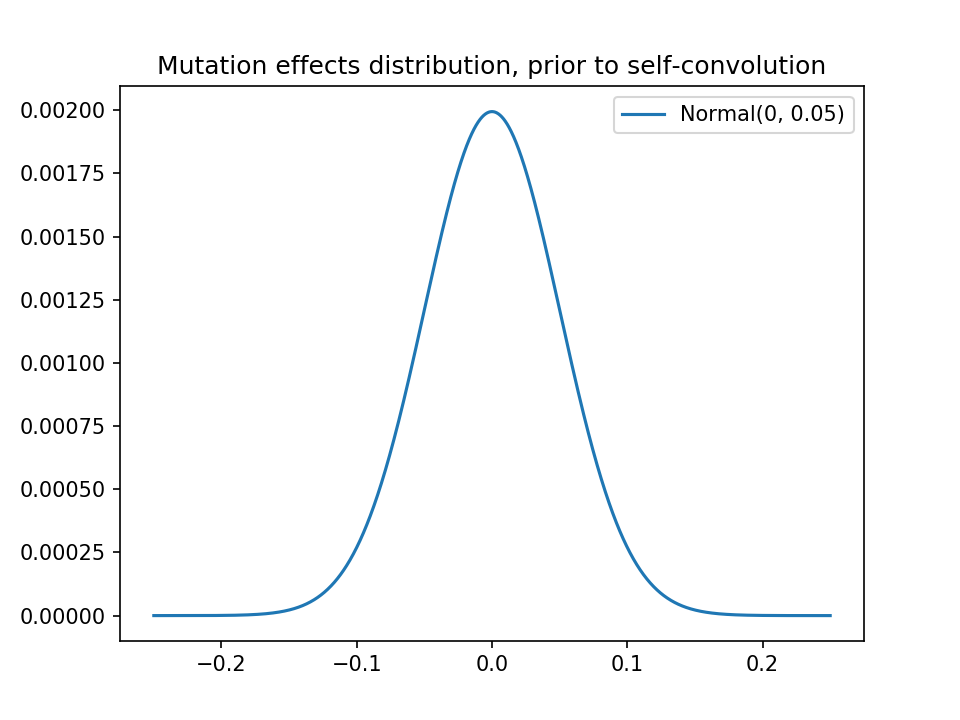

In [11]:
fig = plt.figure() # create a figure
axes = fig.gca()   # get current axes
effects.plot(axes, label='Normal(0, 0.05)')
axes.legend(loc='best')
axes.set_title('Mutation effects distribution, prior to self-convolution');

### $L$-fold convolution

`GaussianEffects` is a subclass of the class `EffectsDistribution`. In order to obtain the $L$-fold convolution of an `EffectsDistribution` instance, we set the number of mutations per offspring to $L = 2^n$ and the log-number of loci to $n.$ In theory, the standard deviation of the result should be $n$ times the standard deviation of the original distribution.

The following function plots&hellip;???. We immediately check to see that it reproduces the plot above when the standard devition is 0.005, the number of mutations per organism is 1, and the number of loci is 1.

<IPython.core.display.Javascript object>


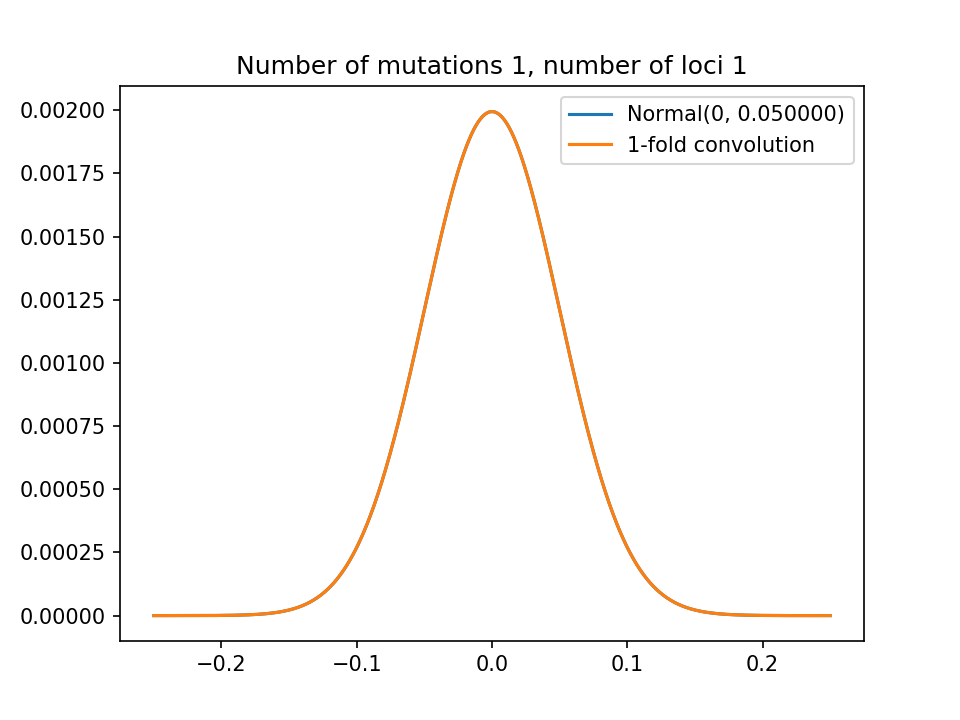

In [12]:
def plot(std, number_of_mutations, log_number_of_loci):
    fig = plt.figure()
    axes = fig.gca()
    effects = GaussianEffects(n_rates=1001, std=std, number_of_mutations=None)
    effects.plot(axes, label='Normal(0, {0:f})'.format(std))
    effects.iid_effects(number_of_mutations, log_number_of_loci, truncate_self_convolution=False)
    effects.plot(axes, label='{0}-fold convolution'.format(number_of_mutations));
    axes.legend(loc='best')
    axes.set_title('Number of mutations {0}, number of loci {1}'.format(number_of_mutations,
                                                                        2 ** log_number_of_loci))
    return effects, fig

plot(0.05, 1, 0);

There are severe edge effects in the 4-fold convolution of a zero-mean, normal distribution when the results are limited to the interval $[-5z,\, 5z].$

<IPython.core.display.Javascript object>


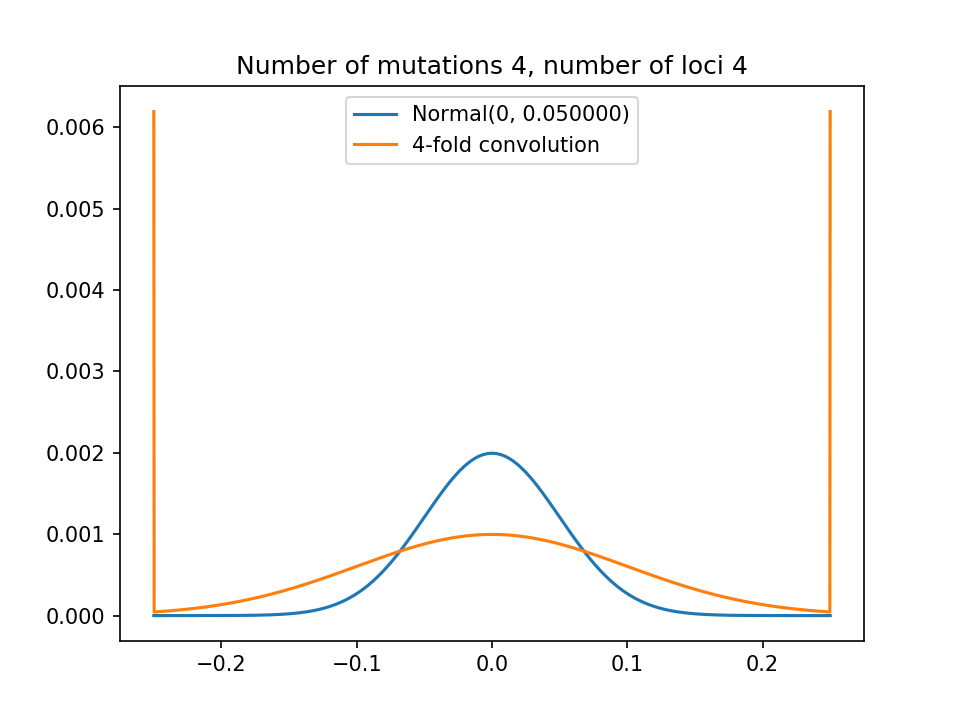

In [13]:
plot(0.05, 2**2, 2);

So we set the standard deviation of the original distribution to $0.05/n,$ and expect the resulting distribution to approximate $\text{Normal}(0,\, 0.05).$

<IPython.core.display.Javascript object>


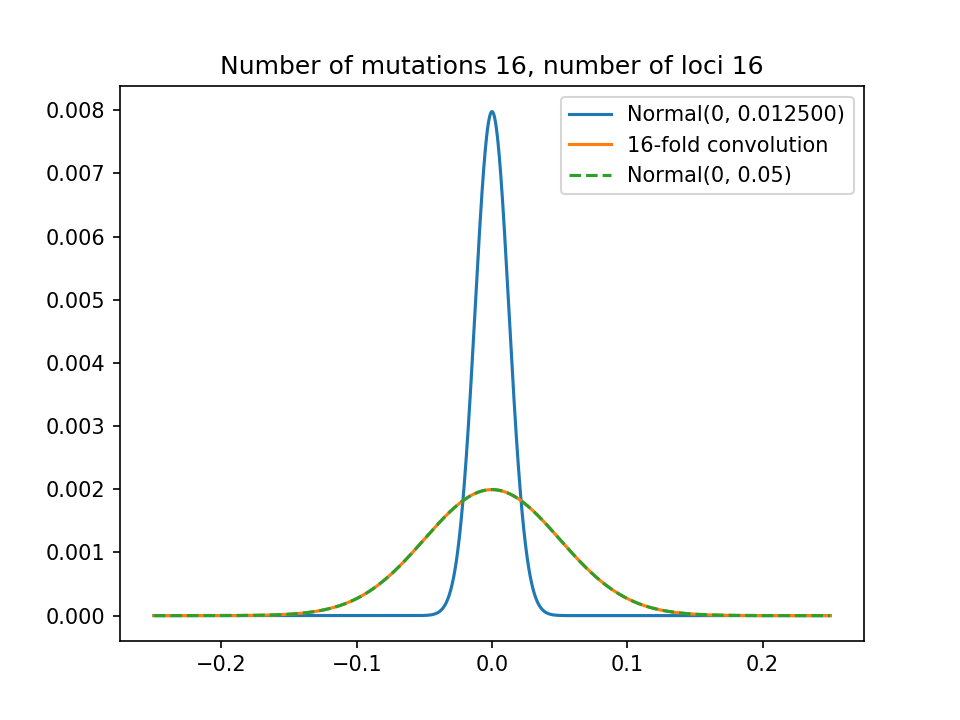

In [14]:
n=4
plot(0.05/n, 2**n, n);
plt.plot(x, p, label='Normal(0, 0.05)', ls='--')
plt.legend(loc='best');

Verify that the mean of the result is about zero, and that the variance is about $0.05^2 = 0.0025.$

In [15]:
effects.mean_and_variance()

(0.0, 0.00249996848364145)

### Mutation effects

Now we consider $L = 2^n$ loci with 1 mutation per offspring. The standard deviation of the initial Gaussian distribution is equal to $0.02,$ as in Section 5.3 of the BS article. The expected number of mutations at any given site is $\mu = 1 / L.$ Thus, to obtain the distribution of probability over mutation effects at a site, we scale  the probabilities in the initial distribution by $\mu,$ and then add $1 - 1/L$ to the probability that mutation at the site has zero effect on the growth rate (fitness) of the offspring.

**TO DO**

## Symmetrized Gamma distribution of mutation effects

### Lumped effects

In [16]:
asym = GammaEffects(percent_beneficial=0.001)  # BS Sect 5.4
sym = GammaEffects(percent_beneficial=None)

Verify that the beneficial tail of the reweighted distribution has been scaled to 0.001.

In [17]:
mid = len(asym) // 2
beneficial = asym[mid+1:]
non_beneficial = asym[:mid+1]
s='beneficial sum {0:f} for {1} elements, non-beneficial sum {2:f} for {3} elements'
s.format(np.sum(beneficial), len(beneficial), np.sum(non_beneficial), len(non_beneficial))

'beneficial sum 0.001000 for 500 elements, non-beneficial sum 0.999000 for 501 elements'

Verify that the mean and variance of the (normalized) upper tail of the symmetrized Gamma distribution are close to the values $\alpha/\beta$ and $\alpha/\beta^2,$ respectively.

In [18]:
mid = len(sym) // 2
x = sym.domain[mid:]
p = np.array(sym[mid:])
p[0] /= 2
p /= np.sum(p)
mean, variance = mean_and_variance(x, p)
s='mean, variance: {0:e}, {1:e} (expected: {2:e}, {3:e})'
s.format(mean, variance, sym.alpha/sym.beta, sym.alpha/sym.beta**2)

'mean, variance: 9.832229e-04, 2.049301e-06 (expected: 1.000000e-03, 2.000000e-06)'

It is clear from the following plot why the observed mean and variance are not particularly close to the theoretically predicted values. The probability mass is concentrated on just a few discrete values. There is no reason to think that the discrete distribution would approximate the continuous distribution closely.

<IPython.core.display.Javascript object>


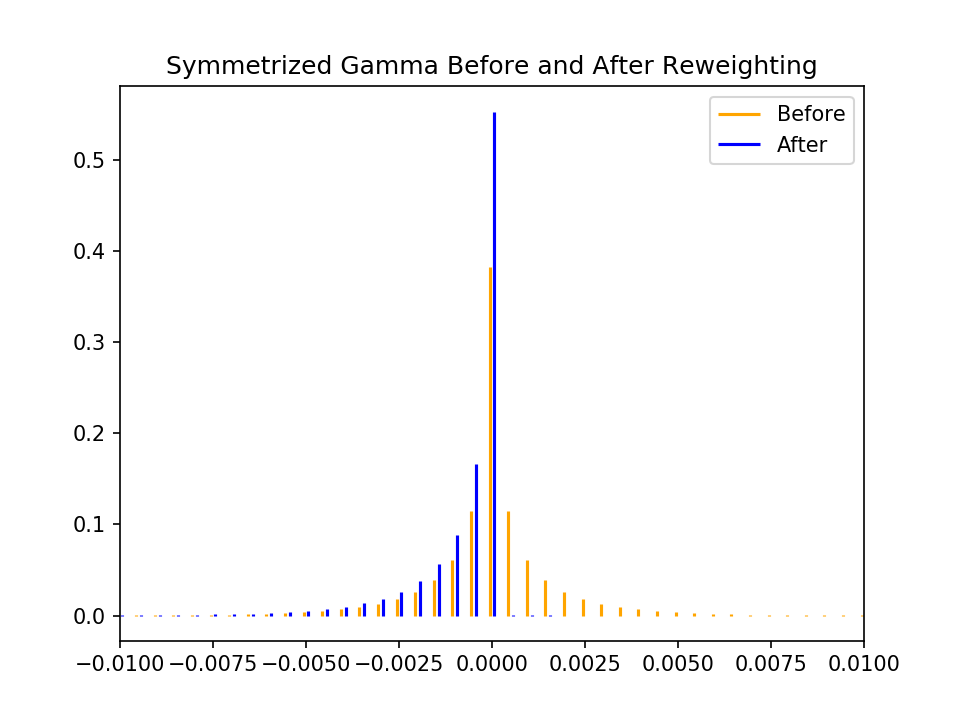

In [19]:
fig = plt.figure()
axes = fig.gca()
shift = (sym.domain[1] - sym.domain[0]) / 8
plt.title('Symmetrized Gamma Before and After Reweighting')
sym.vlines(axes, -shift, label='Before').set_color('orange')
asym.vlines(axes, shift, label='After').set_color('blue')
plt.legend(loc='best')
plt.xlim(-0.01, 0.01);

Note that there are zoom and pan controls on the figure.

### Independent, identically distributed, additive mutation effects at loci

<IPython.core.display.Javascript object>


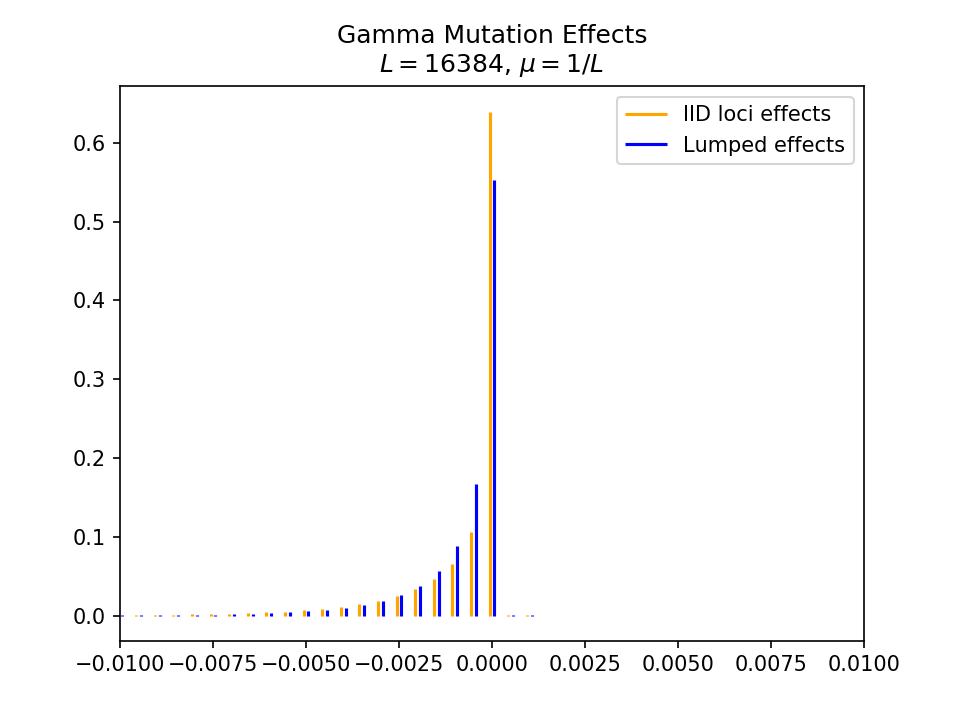

In [20]:
log_L = 14
iid = GammaEffects(percent_beneficial=0.001, number_of_mutations=1, log_number_of_loci=log_L)
fig = plt.figure()
axes = fig.gca()
shift = (asym.domain[1] - asym.domain[0]) / 8
plt.title('Gamma Mutation Effects\n$L={0}$, $\mu=1/L$'.format(2**log_L))
iid.vlines(axes, -shift, label='IID loci effects').set_color('orange')
asym.vlines(axes, shift, label='Lumped effects').set_color('blue')
plt.legend(loc='best')
plt.xlim(-0.01, 0.01);

**The ratio of the probability of deleterious mutation to the probability of beneficial mutation is somewhat greater with additive iid effects than with lumped effects.**

The probability of no mutation effect on growth rate is excluded from the following calculations.

In [21]:
n = len(asym) // 2
lumped_ratio = np.sum(asym[:n]) / np.sum(asym[n+1:])
iid_ratio = np.sum(iid[:n]) / np.sum(iid[n+1:])
'Deleterious-to-beneficial ratio: lumped {0:f}, iid {1:f}'.format(lumped_ratio, iid_ratio)

'Deleterious-to-beneficial ratio: lumped 445.763897, iid 469.890610'

Now we animate two evolutionary processes that differ only in the distribution of probability over mutation effects on the growth rates of offspring. The distributions are those of the preceding figure.

<IPython.core.display.Javascript object>


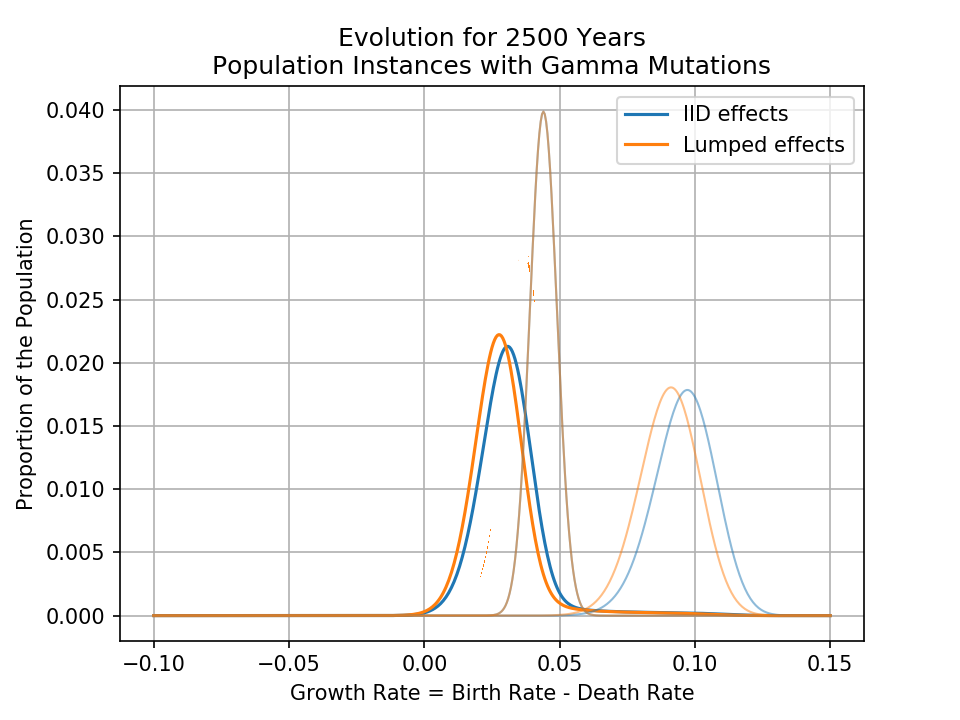

In [22]:
initial_distribution = GaussianRates(asym.n_rates)
lumped_ev = Evolution(Population(initial_distribution, asym))
iid_ev = Evolution(Population(initial_distribution, iid))
lumped_ev(2500)
iid_ev(2500)
animate([iid_ev, lumped_ev], ['IID effects', 'Lumped effects'], 
        subtitle='\nPopulation Instances with Gamma Mutations')

Repeat with `BS_Population` instances zeroing growth-rate frequencies less than $10^{-9}$ times the maximum of the frequencies (as Basener's script does).

<IPython.core.display.Javascript object>


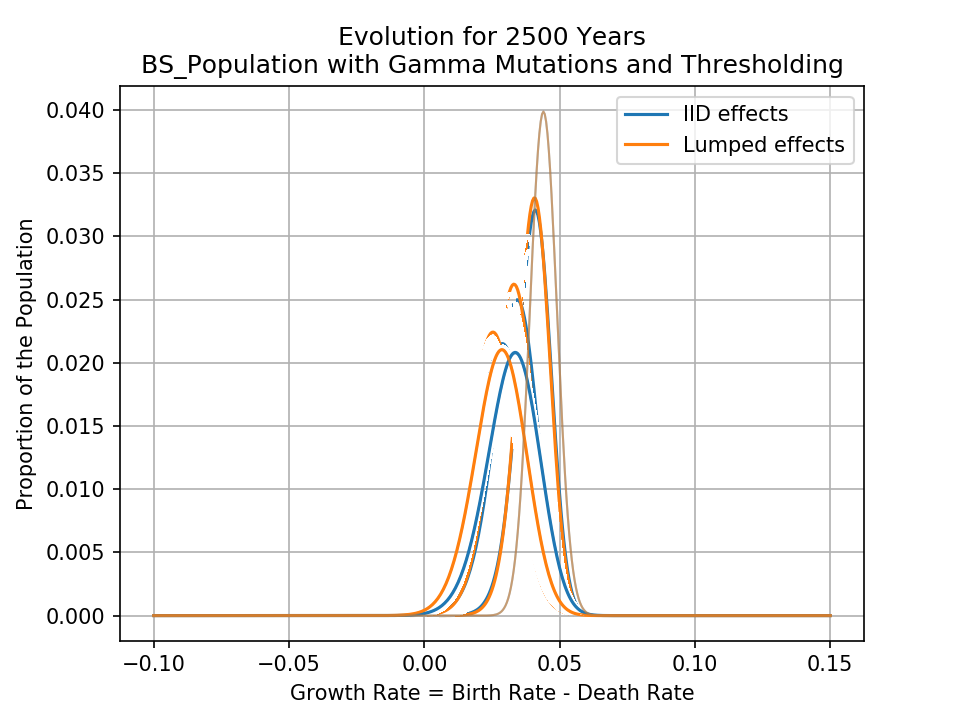

In [23]:
initial_distribution = GaussianRates(asym.n_rates)
lumped_ev = Evolution(BS_Population(initial_distribution, asym, threshold_norm=np.max))
iid_ev = Evolution(BS_Population(initial_distribution, iid, threshold_norm=np.max))
lumped_ev(2500)
iid_ev(2500)
animate([iid_ev, lumped_ev], ['IID effects', 'Lumped effects'], 
        subtitle='\nBS_Population with Gamma Mutations and Thresholding')